In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime

In [2]:
# Leer y parsear el archivo log
def cargar_datos(path):
    with open(path, encoding='utf-8') as f:
        lineas = f.readlines()

    registros = []
    for linea in lineas:
        match = re.match(r"- (\d{4}-\d{2}-\d{2} \d{2}:\d{2}) \| ([\d.]+) min \| (.+)", linea.strip())
        if not match:
            continue
        fecha = datetime.strptime(match[1], '%Y-%m-%d %H:%M')
        minutos = float(match[2])
        campos = [c.strip() for c in match[3].split("|")]

        estado = campos[0] if campos else match[3]
        peaje = campos[1] if len(campos) >= 2 else None

        # El campo de sentido fue evolucionando (ver main_mlg.py):
        #   2 campos -> histórico sin sentido, todo corresponde a la ida
        #   3 campos -> solo etiqueta legible (formato de transición)
        #   4+ campos -> clave estable "ida"/"vuelta" + etiqueta legible
        if len(campos) >= 4:
            sentido = campos[2]
            sentido_label = campos[3]
        elif len(campos) == 3:
            sentido_label = campos[2]
            origen = sentido_label.split("→")[0]
            sentido = "vuelta" if ("arbella" in origen or "olicia" in origen) else "ida"
        else:
            sentido, sentido_label = "ida", None

        registros.append((fecha, minutos, estado, peaje, sentido, sentido_label))

    df = pd.DataFrame(registros, columns=["fecha", "minutos", "estado", "peaje", "sentido", "sentido_label"])
    df["hora"] = df["fecha"].dt.hour
    df["dia_semana"] = df["fecha"].dt.day_name()
    return df

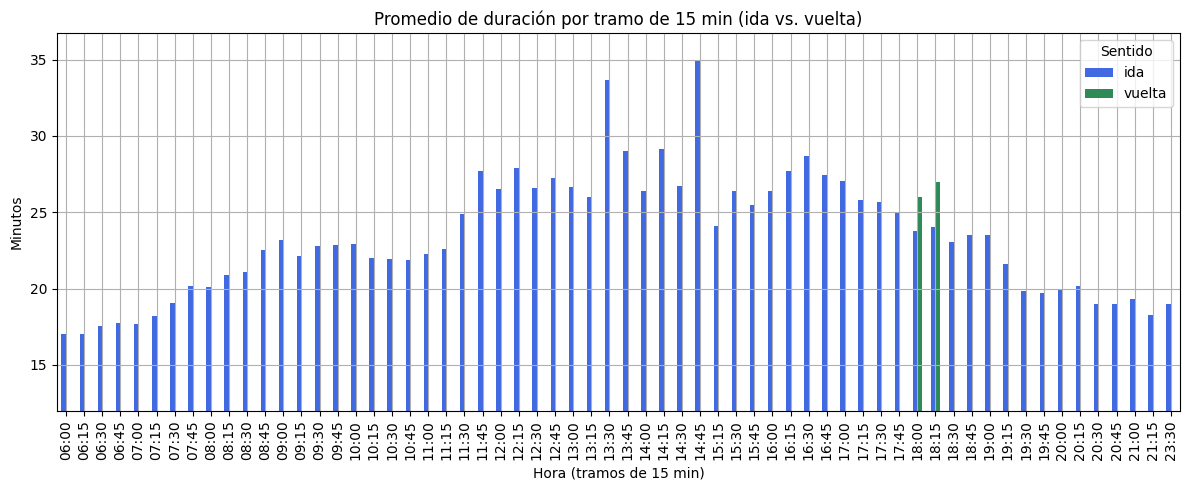

In [3]:
# Cargar datos
df = cargar_datos("trafico_log_mlg.md")

# Crear columna de tramos de 15 min
df["hora_15min"] = df["fecha"].dt.strftime("%H:%M").apply(
    lambda x: f"{x[:2]}:{int(x[3:])//15*15:02d}"
)

# Gráfico 1: duración por tramo de 15 min, separado por sentido (ida vs. vuelta)
tabla_tramos = df.pivot_table(index="hora_15min", columns="sentido", values="minutos", aggfunc="mean")
min_y = max(0, tabla_tramos.min().min() - 5)
tabla_tramos.plot(kind="bar", figsize=(12, 5), color=["royalblue", "seagreen"])
plt.title("Promedio de duración por tramo de 15 min (ida vs. vuelta)")
plt.ylabel("Minutos")
plt.xlabel("Hora (tramos de 15 min)")
plt.ylim(min_y, None)
plt.legend(title="Sentido")
plt.grid(True)
plt.tight_layout()
plt.savefig("grafico_tramos_15min_mlg.png", dpi=200)  # <-- Exporta a imagen
plt.show()

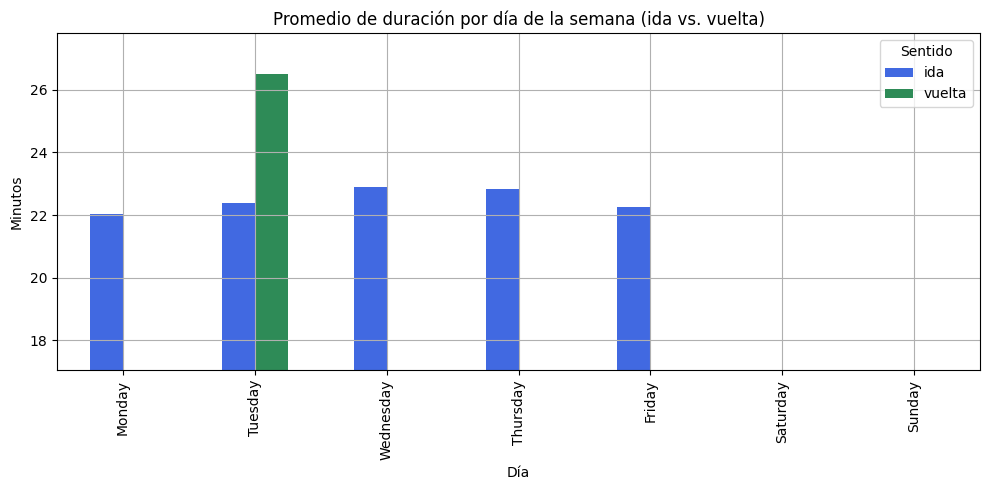

In [4]:
# Gráfico 2: promedio por día de la semana, separado por sentido (ida vs. vuelta)
dias_orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
tabla_dias = df.pivot_table(index="dia_semana", columns="sentido", values="minutos", aggfunc="mean").reindex(dias_orden)
min_y_dia = max(0, tabla_dias.min().min() - 5)
tabla_dias.plot(kind="bar", figsize=(10, 5), color=["royalblue", "seagreen"])
plt.title("Promedio de duración por día de la semana (ida vs. vuelta)")
plt.ylabel("Minutos")
plt.xlabel("Día")
plt.ylim(min_y_dia, None)
plt.legend(title="Sentido")
plt.grid(True)
plt.tight_layout()
plt.savefig("grafico_dias_semana_mlg.png", dpi=200)  # <-- Exporta a imagen
plt.show()

In [5]:
# Mostrar picos de tráfico
umbral = 20
picos = df[df["minutos"] > umbral].copy()
picos["fecha_str"] = picos["fecha"].dt.strftime('%Y-%m-%d %H:%M')
picos["minutos"] = picos["minutos"].astype(int)
print(f"🔺 Registros con tráfico alto (>{umbral}min):")
display(picos[["fecha_str", "minutos", "sentido", "estado"]])

🔺 Registros con tráfico alto (>20min):


,fecha_str,minutos,sentido,estado
0,2025-07-22 17:35,27,ida,🚨 ALTO
1,2025-07-22 17:37,27,ida,🚨 ALTO
2,2025-07-22 15:37,27,ida,🚨 ALTO
3,2025-07-22 15:44,25,ida,🚨 ALTO
4,2025-07-22 15:55,24,ida,🚨 ALTO
...,...,...,...,...
5310,2026-08-04 18:10,32,ida,AUTO
5311,2026-08-04 18:13,33,ida,AUTO
5312,2026-08-04 18:13,26,vuelta,AUTO
5313,2026-08-04 18:16,32,ida,AUTO


In [6]:
# Verificar valores únicos en 'estado' y registros por sentido
print("Valores únicos en 'estado':", df['estado'].unique())
print("\nRegistros por sentido:")
display(df['sentido'].value_counts())

Valores únicos en 'estado': ['🚨 ALTO' '✅ NORMAL' 'ALTO' 'AUTO']

Registros por sentido:


sentido
ida       5313
vuelta       2
Name: count, dtype: int64